# **MILESTONE 2**


**TASK5**

In [27]:
from google.colab import drive
drive.mount('/content/drive')

# Setup Kaggle API
!mkdir -p ~/.kaggle
!cp /content/drive/MyDrive/kaggle/kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# Download dog-breed-identification dataset
!kaggle competitions download -c dog-breed-identification -p /content/dog_breed_data/


 95% 655M/691M [00:03<00:00, 235MB/s]
100% 691M/691M [00:06<00:00, 106MB/s]


In [ ]:
import zipfile, os

zip_dir = "/content/dog_breed_data"
for f in os.listdir(zip_dir):
    if f.endswith(".zip"):
        with zipfile.ZipFile(os.path.join(zip_dir, f), 'r') as zf:
            zf.extractall(zip_dir)

print("✅ Files extracted:", os.listdir(zip_dir))


✅ Files extracted: ['train', 'dog-breed-identification.zip', 'labels.csv', 'sample_submission.csv', 'test']


In [ ]:
import pandas as pd
import os

# Base dataset path
base_path = "/content/dog_breed_data"

# Paths
labels_csv = os.path.join(base_path, "labels.csv")
train_dir = os.path.join(base_path, "train")
test_dir = os.path.join(base_path, "test")

# Load labels.csv
labels_all = pd.read_csv(labels_csv)
print("✅ Data loaded:", labels_all.shape)
labels_all.head()


✅ Data loaded: (10222, 2)


,id,breed
0,000bec180eb18c7604dcecc8fe0dba07,boston_bull
1,001513dfcb2ffafc82cccf4d8bbaba97,dingo
2,001cdf01b096e06d78e9e5112d419397,pekinese
3,00214f311d5d2247d5dfe4fe24b2303d,bluetick
4,0021f9ceb3235effd7fcde7f7538ed62,golden_retriever


In [ ]:
labels_all['id'] = labels_all['id'] + ".jpg"

# Define random state
RANDOM_STATE = 42   # you can choose any integer

# Train-validation split
from sklearn.model_selection import train_test_split
train_df, val_df = train_test_split(
    labels_all,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=labels_all['breed']
)


In [ ]:

# Constants
SIZE = (350, 350)
BATCH_SIZE = 32
NUM_CLASSES = len(labels_all['breed'].unique())
LEARNING_RATE = 0.001
DROPOUT_RATE = 0.7
EPOCHS = 5

In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# ImageDataGenerators with augmentation
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,        # randomly rotate images (0–20 degrees)
    width_shift_range=0.2,    # randomly shift images horizontally (20%)
    height_shift_range=0.2,   # randomly shift images vertically (20%)
    shear_range=0.2,          # shear transformation
    zoom_range=0.2,           # zoom in/out
    horizontal_flip=True,     # randomly flip images horizontally
    fill_mode='nearest'       # fill pixels after rotation/shift
)

# Validation & Test: only rescale (no augmentation)
val_datagen = ImageDataGenerator(rescale=1./255)
test_datagen = ImageDataGenerator(rescale=1./255)


In [ ]:
# Data Generators
train_generator = train_datagen.flow_from_dataframe(
    dataframe=train_df,
    directory=train_dir,
    x_col='id',
    y_col='breed',
    target_size=SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)

val_generator = val_datagen.flow_from_dataframe(
    dataframe=val_df,
    directory=train_dir,
    x_col='id',
    y_col='breed',
    target_size=SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)

# ⚡ Test data: test folder has no labels, so we use class_mode=None
test_generator = test_datagen.flow_from_dataframe(
    dataframe=pd.DataFrame({'id': os.listdir(test_dir)}),
    directory=test_dir,
    x_col='id',
    y_col='breed',
    target_size=SIZE,
    batch_size=BATCH_SIZE,
    class_mode=None,
    shuffle=False
)

Found 8177 validated image filenames belonging to 120 classes.
Found 2045 validated image filenames belonging to 120 classes.
Found 10357 validated image filenames.


In [ ]:
# ================== Imports ==================
import os
import pandas as pd
import numpy as np

# TensorFlow / Keras
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import Xception
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, GlobalAveragePooling2D, Dropout, Dense
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint


In [ ]:
# ================== Base model ==================
input_tensor = Input(shape=(SIZE[0], SIZE[1], 3))
base_model = Xception(weights='imagenet', include_top=False, input_tensor=input_tensor)
base_model.trainable = False

# Output layer
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dropout(DROPOUT_RATE)(x)
output = Dense(NUM_CLASSES, activation='softmax')(x)

# Build model
model = Model(inputs=input_tensor, outputs=output)

# Compile model
model.compile(optimizer=Adam(learning_rate=LEARNING_RATE),
              loss='categorical_crossentropy',
              metrics=['accuracy'])

# ================== Callbacks ==================
early_stopping = EarlyStopping(monitor='val_loss', patience=4, verbose=1)
model_checkpoint = ModelCheckpoint('model.h5', monitor='val_loss', save_best_only=True, verbose=1)

# ================== Training ==================
history = model.fit(
    train_generator,
    validation_data=val_generator,
    steps_per_epoch=train_generator.samples // BATCH_SIZE,
    validation_steps=val_generator.samples // BATCH_SIZE,
    epochs=EPOCHS,
    callbacks=[early_stopping, model_checkpoint]
)

83683744/83683744 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/5
255/255 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.3989 - loss: 3.2432
Epoch 1: val_loss improved from inf to 0.62804, saving model to model.h5


255/255 ━━━━━━━━━━━━━━━━━━━━ 387s 1s/step - accuracy: 0.3998 - loss: 3.2386 - val_accuracy: 0.8874 - val_loss: 0.6280
Epoch 2/5
  1/255 ━━━━━━━━━━━━━━━━━━━━ 1:20 315ms/step - accuracy: 0.8438 - loss: 0.7797

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:116: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()



Epoch 2: val_loss improved from 0.62804 to 0.62621, saving model to model.h5


255/255 ━━━━━━━━━━━━━━━━━━━━ 29s 115ms/step - accuracy: 0.8438 - loss: 0.7797 - val_accuracy: 0.8884 - val_loss: 0.6262
Epoch 3/5
255/255 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.8505 - loss: 0.7040
Epoch 3: val_loss improved from 0.62621 to 0.39814, saving model to model.h5


255/255 ━━━━━━━━━━━━━━━━━━━━ 295s 1s/step - accuracy: 0.8505 - loss: 0.7037 - val_accuracy: 0.9008 - val_loss: 0.3981
Epoch 4/5
  1/255 ━━━━━━━━━━━━━━━━━━━━ 1:18 310ms/step - accuracy: 0.8438 - loss: 0.6498
Epoch 4: val_loss improved from 0.39814 to 0.39749, saving model to model.h5


255/255 ━━━━━━━━━━━━━━━━━━━━ 40s 157ms/step - accuracy: 0.8438 - loss: 0.6498 - val_accuracy: 0.8998 - val_loss: 0.3975
Epoch 5/5
255/255 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.8727 - loss: 0.5092
Epoch 5: val_loss improved from 0.39749 to 0.34600, saving model to model.h5


255/255 ━━━━━━━━━━━━━━━━━━━━ 348s 1s/step - accuracy: 0.8727 - loss: 0.5091 - val_accuracy: 0.9018 - val_loss: 0.3460


In [ ]:
model.save('/content/drive/MyDrive/AI Model for Dog Breed Detection and Information Generation/Xception_model.h5')

In [28]:

from tensorflow.keras.models import load_model

model = load_model('/content/drive/MyDrive/AI Model for Dog Breed Detection and Information Generation/Xception_model.h5')

print("Evaluating on validation data:")
val_score = model.evaluate(val_generator, verbose=1)

print(f"\nValidation Loss: {val_score[0]:.4f}")
print(f"Validation Accuracy: {val_score[1]:.4f}")

# Notes:
# val_score[0] = Test Loss (smaller = better)
# val_score[1] = Test Accuracy (bigger = better)


Evaluating on validation data:
64/64 ━━━━━━━━━━━━━━━━━━━━ 86s 494ms/step - accuracy: 0.8931 - loss: 0.3810

Validation Loss: 0.3447
Validation Accuracy: 0.9056


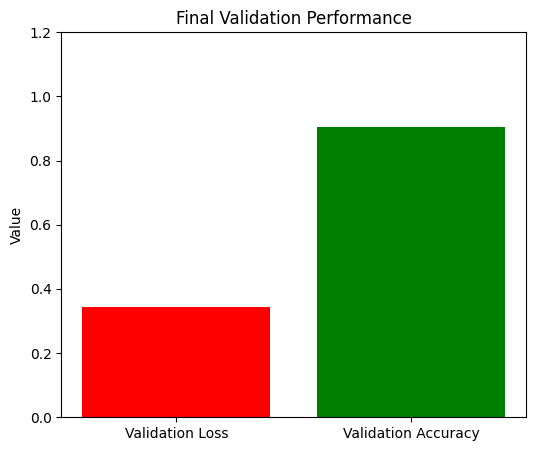

In [ ]:
import matplotlib.pyplot as plt

# Already evaluated earlier
val_loss = val_score[0]
val_acc = val_score[1]

metrics = ['Validation Loss', 'Validation Accuracy']
values = [val_loss, val_acc]

plt.figure(figsize=(6,5))
plt.bar(metrics, values, color=['red', 'green'])
plt.title("Final Validation Performance")
plt.ylabel("Value")
plt.ylim(0, 1.2)
plt.show()


In [ ]:
import pandas as pd
import os
import numpy as np


# Make Predictions on Test Data

test_predictions = model.predict(test_generator, verbose=1)

# Get the predicted classes
predicted_classes = np.argmax(test_predictions, axis=1)

# Get class names from the training generator
class_names = list(train_generator.class_indices.keys())

# Get test filenames
test_filenames = test_generator.filenames

# Predicted breeds
predicted_breeds = [class_names[i] for i in predicted_classes]

# Extract image IDs from test filenames (remove path + .jpg)
test_ids = [os.path.splitext(os.path.basename(f))[0] for f in test_filenames]


# Build Results DataFrame

results_df = pd.DataFrame({
    'filename': test_filenames,
    'id': test_ids,
    'predicted_breed': predicted_breeds,
    'confidence': np.max(test_predictions, axis=1)
})

print(f"Predictions completed for {len(results_df)} test images")
print("\nFirst 10 predictions:")
print(results_df.head(10))


# Save Predictions
results_df.to_csv('/content/drive/MyDrive/AI Model for Dog Breed Detection and Information Generation/test_predictions.csv', index=False)

print("✅ Predictions saved as test_predictions.csv in MyDrive root folder")


324/324 ━━━━━━━━━━━━━━━━━━━━ 150s 427ms/step
Predictions completed for 10357 test images

First 10 predictions:
                               filename                                id  \
0  c4b07fbca9738b950b1c989a4708429f.jpg  c4b07fbca9738b950b1c989a4708429f   
1  bdd1b7cbaa56034c29878e489c57b14a.jpg  bdd1b7cbaa56034c29878e489c57b14a   
2  8f63f4918ebda3546c563f7520a46dcf.jpg  8f63f4918ebda3546c563f7520a46dcf   
3  744cda70cb9f2082f4cf9b591e288585.jpg  744cda70cb9f2082f4cf9b591e288585   
4  c565fa66f48e9261f5d6549660ed5f1d.jpg  c565fa66f48e9261f5d6549660ed5f1d   
5  0a4ef19459cd2100977b052de5f46231.jpg  0a4ef19459cd2100977b052de5f46231   
6  e5de4eec61d00ee4834ff0153f90ed41.jpg  e5de4eec61d00ee4834ff0153f90ed41   
7  1255d7d9db559f1c70b04dc74b002a98.jpg  1255d7d9db559f1c70b04dc74b002a98   
8  338d2abfc6858ed3172ede3bc74b5788.jpg  338d2abfc6858ed3172ede3bc74b5788   
9  99c85e92f484f931d0fcccf6e062c73d.jpg  99c85e92f484f931d0fcccf6e062c73d   

      predicted_breed  confidence  
0   

**TASK6**

In [ ]:
from tensorflow.keras.applications import EfficientNetB3
from tensorflow.keras.layers import Input, GlobalAveragePooling2D, Dropout, Dense
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

# ================== Base model ==================
input_tensor = Input(shape=(SIZE[0], SIZE[1], 3))
base_model = EfficientNetB3(weights='imagenet', include_top=False, input_tensor=input_tensor)
base_model.trainable = False   # Freeze pretrained layers

# Output layer
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dropout(DROPOUT_RATE)(x)
output = Dense(NUM_CLASSES, activation='softmax')(x)

# Build model
model = Model(inputs=input_tensor, outputs=output)

# Compile model
model.compile(optimizer=Adam(learning_rate=LEARNING_RATE),
              loss='categorical_crossentropy',
              metrics=['accuracy'])

# ================== Callbacks ==================
early_stopping = EarlyStopping(monitor='val_loss', patience=4, verbose=1)
model_checkpoint = ModelCheckpoint('efficientnet_model.h5', monitor='val_loss', save_best_only=True, verbose=1)

# ================== Training ==================
history = model.fit(
    train_generator,
    validation_data=val_generator,
    steps_per_epoch=train_generator.samples // BATCH_SIZE,
    validation_steps=val_generator.samples // BATCH_SIZE,
    epochs=EPOCHS,
    callbacks=[early_stopping, model_checkpoint]
)


43941136/43941136 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/5
255/255 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.0076 - loss: 4.9889
Epoch 1: val_loss improved from inf to 4.84492, saving model to efficientnet_model.h5


255/255 ━━━━━━━━━━━━━━━━━━━━ 367s 1s/step - accuracy: 0.0076 - loss: 4.9888 - val_accuracy: 0.0089 - val_loss: 4.8449
Epoch 2/5
  1/255 ━━━━━━━━━━━━━━━━━━━━ 39s 154ms/step - accuracy: 0.0000e+00 - loss: 5.0834
Epoch 2: val_loss improved from 4.84492 to 4.83955, saving model to efficientnet_model.h5


255/255 ━━━━━━━━━━━━━━━━━━━━ 11s 43ms/step - accuracy: 0.0000e+00 - loss: 5.0834 - val_accuracy: 0.0089 - val_loss: 4.8396
Epoch 3/5
255/255 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.0088 - loss: 4.9392
Epoch 3: val_loss improved from 4.83955 to 4.83333, saving model to efficientnet_model.h5


255/255 ━━━━━━━━━━━━━━━━━━━━ 281s 1s/step - accuracy: 0.0088 - loss: 4.9393 - val_accuracy: 0.0109 - val_loss: 4.8333
Epoch 4/5
  1/255 ━━━━━━━━━━━━━━━━━━━━ 37s 149ms/step - accuracy: 0.0000e+00 - loss: 4.9381
Epoch 4: val_loss improved from 4.83333 to 4.83309, saving model to efficientnet_model.h5


255/255 ━━━━━━━━━━━━━━━━━━━━ 20s 78ms/step - accuracy: 0.0000e+00 - loss: 4.9381 - val_accuracy: 0.0104 - val_loss: 4.8331
Epoch 5/5
255/255 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.0096 - loss: 4.9537
Epoch 5: val_loss improved from 4.83309 to 4.81798, saving model to efficientnet_model.h5


255/255 ━━━━━━━━━━━━━━━━━━━━ 322s 1s/step - accuracy: 0.0096 - loss: 4.9537 - val_accuracy: 0.0084 - val_loss: 4.8180


In [ ]:
model.save('/content/drive/MyDrive/AI Model for Dog Breed Detection and Information Generation/EfficientNetB3_model.h5')

In [ ]:

from tensorflow.keras.models import load_model

model = load_model('/content/drive/MyDrive/AI Model for Dog Breed Detection and Information Generation/EfficientNetB3_model.h5')

print("Evaluating on validation data:")
val_score = model.evaluate(val_generator, verbose=1)

print(f"\nValidation Loss: {val_score[0]:.4f}")
print(f"Validation Accuracy: {val_score[1]:.4f}")

# Notes:
# val_score[0] = Test Loss (smaller = better)
# val_score[1] = Test Accuracy (bigger = better)


Evaluating on validation data:
64/64 ━━━━━━━━━━━━━━━━━━━━ 45s 515ms/step - accuracy: 0.8989 - loss: 0.3654

Validation Loss: 0.3447
Validation Accuracy: 0.9056


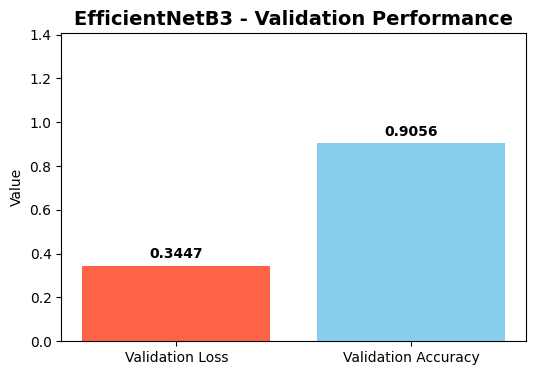

In [ ]:
import matplotlib.pyplot as plt

# Your final evaluation results
val_loss = 0.3447
val_acc = 0.9056

# Bar chart with different colors
plt.figure(figsize=(6,4))
bars = plt.bar(["Validation Loss", "Validation Accuracy"],
               [val_loss, val_acc],
               color=["tomato", "skyblue"])

# Add values on top of bars
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.02, f"{yval:.4f}",
             ha="center", va="bottom", fontsize=10, fontweight="bold")

plt.title("EfficientNetB3 - Validation Performance", fontsize=14, fontweight="bold")
plt.ylabel("Value")
plt.ylim(0, max(val_loss, val_acc) + 0.5)
plt.show()


In [ ]:
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.layers import Input, GlobalAveragePooling2D, Dropout, Dense
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

# ================== Base model ==================
input_tensor = Input(shape=(SIZE[0], SIZE[1], 3))
base_model = ResNet50(weights='imagenet', include_top=False, input_tensor=input_tensor)
base_model.trainable = False   # Freeze pretrained layers

# Output layer
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dropout(DROPOUT_RATE)(x)
output = Dense(NUM_CLASSES, activation='softmax')(x)

# Build model
model = Model(inputs=input_tensor, outputs=output)

# Compile model
model.compile(optimizer=Adam(learning_rate=LEARNING_RATE),
              loss='categorical_crossentropy',
              metrics=['accuracy'])

# ================== Callbacks ==================
early_stopping = EarlyStopping(monitor='val_loss', patience=4, verbose=1)
model_checkpoint = ModelCheckpoint('resnet50_model.h5', monitor='val_loss', save_best_only=True, verbose=1)

# ================== Training ==================
history = model.fit(
    train_generator,
    validation_data=val_generator,
    steps_per_epoch=train_generator.samples // BATCH_SIZE,
    validation_steps=val_generator.samples // BATCH_SIZE,
    epochs=EPOCHS,
    callbacks=[early_stopping, model_checkpoint]
)


94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/5
255/255 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.0089 - loss: 6.7675
Epoch 1: val_loss improved from inf to 4.89452, saving model to resnet50_model.h5


255/255 ━━━━━━━━━━━━━━━━━━━━ 310s 1s/step - accuracy: 0.0089 - loss: 6.7656 - val_accuracy: 0.0084 - val_loss: 4.8945
Epoch 2/5
  1/255 ━━━━━━━━━━━━━━━━━━━━ 50s 200ms/step - accuracy: 0.0000e+00 - loss: 5.5200

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:116: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()



Epoch 2: val_loss improved from 4.89452 to 4.88451, saving model to resnet50_model.h5


255/255 ━━━━━━━━━━━━━━━━━━━━ 13s 52ms/step - accuracy: 0.0000e+00 - loss: 5.5200 - val_accuracy: 0.0099 - val_loss: 4.8845
Epoch 3/5
255/255 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.0101 - loss: 5.5112
Epoch 3: val_loss improved from 4.88451 to 4.86931, saving model to resnet50_model.h5


255/255 ━━━━━━━━━━━━━━━━━━━━ 322s 1s/step - accuracy: 0.0102 - loss: 5.5109 - val_accuracy: 0.0084 - val_loss: 4.8693
Epoch 4/5
  1/255 ━━━━━━━━━━━━━━━━━━━━ 49s 194ms/step - accuracy: 0.0000e+00 - loss: 5.2024
Epoch 4: val_loss improved from 4.86931 to 4.85995, saving model to resnet50_model.h5


255/255 ━━━━━━━━━━━━━━━━━━━━ 13s 52ms/step - accuracy: 0.0000e+00 - loss: 5.2024 - val_accuracy: 0.0089 - val_loss: 4.8599
Epoch 5/5
255/255 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.0129 - loss: 5.3101
Epoch 5: val_loss improved from 4.85995 to 4.83185, saving model to resnet50_model.h5


255/255 ━━━━━━━━━━━━━━━━━━━━ 322s 1s/step - accuracy: 0.0129 - loss: 5.3100 - val_accuracy: 0.0149 - val_loss: 4.8318


In [ ]:
model.save('/content/drive/MyDrive/AI Model for Dog Breed Detection and Information Generation/ResNet50_model.h5')

In [ ]:

from tensorflow.keras.models import load_model

model = load_model('/content/drive/MyDrive/AI Model for Dog Breed Detection and Information Generation/ResNet50_model.h5')

print("Evaluating on validation data:")
val_score = model.evaluate(val_generator, verbose=1)

print(f"\nValidation Loss: {val_score[0]:.4f}")
print(f"Validation Accuracy: {val_score[1]:.4f}")

# Notes:
# val_score[0] = Test Loss (smaller = better)
# val_score[1] = Test Accuracy (bigger = better)

Evaluating on validation data:
64/64 ━━━━━━━━━━━━━━━━━━━━ 28s 331ms/step - accuracy: 0.0162 - loss: 4.8244

Validation Loss: 4.8336
Validation Accuracy: 0.0147


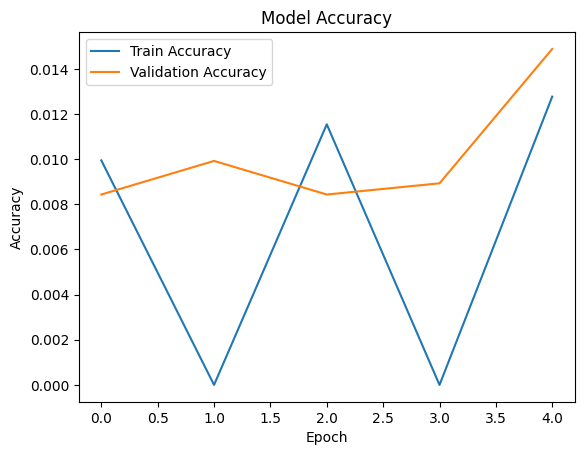

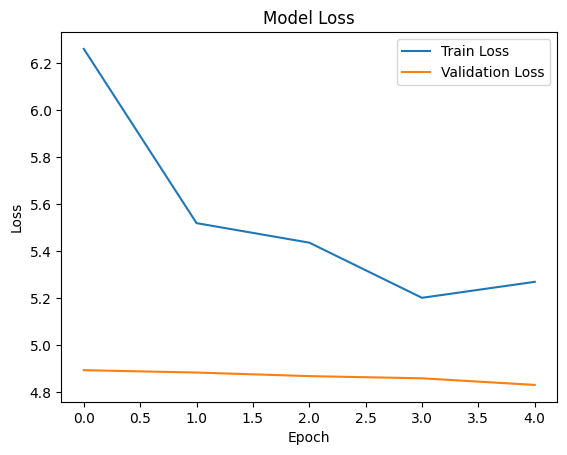

In [ ]:
import matplotlib.pyplot as plt

# Plot Accuracy
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

# Plot Loss
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()
